This can be used in both classfication problem statement and regression problem statement.

In classification :
1.choose k = number of nearest neighbors to consider.
2.Find k nearest data points by step 3.
3.Compute the distance between test point and all training points by either 
  Euclidean Distance : sqrt((x2-x1)^2 + (y2-y1)^2) or Manhattan Distance.
4.Decide which side has majority number of points.
5.Assign test points to that side.

In Regression :
step 1,2,3 are same
4.find average of all this selected nearest data points.

Limitations:
Huge dataset me problem create karega.
Sensitive to Outliers
Sensitive to missing values

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv('student_exam_scores.csv')

In [3]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [ ]:
classifier = KNeighborsClassifier()

In [7]:
parameters = {"n_neighbors": list(range(1, 21))}  # search k=1 to 20

In [ ]:
kcv = GridSearchCV(classifier, parameters, cv=5, scoring="accuracy")

In [10]:
kcv.fit(x_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [1, 2, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,5


In [11]:
y_pred = kcv.predict(x_test)

In [13]:
print(kcv.best_params_)

{'n_neighbors': 5}


In [14]:
print(kcv.best_score_)

0.9866666666666667


In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score,log_loss

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [17]:
precision_score(y_test,y_pred)

1.0

In [19]:
log_loss(y_test,kcv.predict_proba(x_test))

0.026481946278690403

In [20]:
print(confusion_matrix(y_test, y_pred))

[[77  0]
 [ 0 23]]


d:\jbook\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


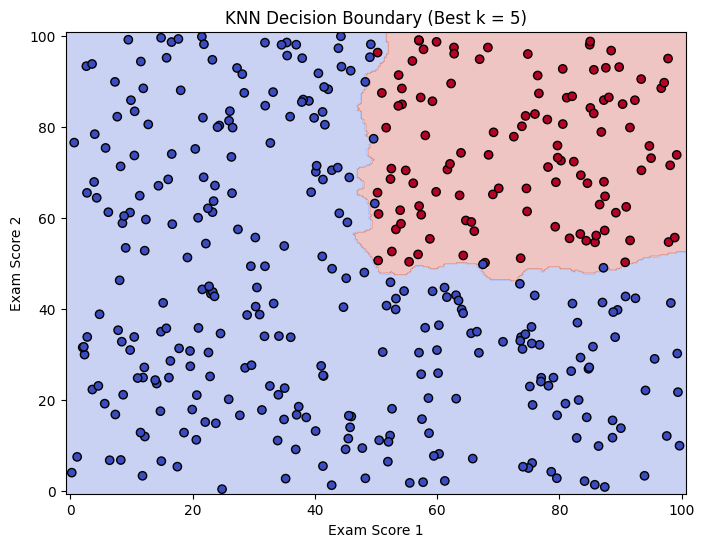

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Get best model from GridSearchCV
best_knn = kcv.best_estimator_

# Create a mesh grid
x_min, x_max = x["Exam Score1"].min() - 1, x["Exam Score1"].max() + 1
y_min, y_max = x["Exam Score2"].min() - 1, x["Exam Score2"].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predict for each point in the grid
Z = best_knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(x["Exam Score1"], x["Exam Score2"], c=y, cmap=plt.cm.coolwarm, edgecolors="k")
plt.xlabel("Exam Score 1")
plt.ylabel("Exam Score 2")
plt.title(f"KNN Decision Boundary (Best k = {kcv.best_params_['n_neighbors']})")
plt.show()
